<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/We_logo.svg/3840px-We_logo.svg.png" alt="WE Logo" width="60" style="margin-bottom:8px"/>

# Telecom Egypt (WE) — ML Project
## Customer Complaint Classification, Summarization & Sentiment Analysis

---

### Background

Telecom Egypt (WE) receives thousands of customer support tickets every day across multiple channels — call center transcripts, the WE app chat, and social media comments. Today, agents read every ticket in full before they can tag its category, gauge how upset the customer is, and decide who should handle it first. This is slow, inconsistent between agents, and makes it hard to spot urgent cases early.

This project simulates a real-world NLP task at WE. You are part of the Data & AI team, and — unlike the Smart Plan project — **there is no historical ticket dataset waiting for you.** The Customer Care team has never systematically logged ticket text before, so before you can train anything, you first have to **construct a realistic synthetic dataset** yourselves, then use it to build an NLP pipeline that, given the raw text of a customer ticket, can:

> **Classify** — which department/category should own this ticket (Billing, Network, Technical Support, Sales/Plans, Other)
> **Summarize** — reduce a long, messy complaint into a 1–2 sentence summary an agent can read in seconds
> **Detect Sentiment** — flag whether the customer is Positive, Neutral, or Negative, so angry customers can be prioritized



---

### General Instructions

- Read each step carefully before writing any code.
- Each step has a clear objective — understand **why** you are doing it, not just **how**.
- Ticket text should be messy on purpose: Arabic, English, Franco-Arabic (Arabic written in Latin letters), emojis, and typos. A too-clean synthetic dataset will teach you nothing about real preprocessing challenges.
- You are expected to make decisions along the way (e.g., how many categories, how imbalanced, how to simulate missing ratings). Document your reasoning in markdown cells.
- There is no single correct answer — justify your choices.


---
## Step 1 — Build a Synthetic Complaint Dataset

### Objective
Since no historical ticket data exists, construct a realistic dataset to prototype the pipeline against.

### Why This Step Matters
The quality of every downstream step — cleaning, features, models — is capped by the quality of this dataset. A synthetic dataset that's too clean or too uniform will hide real-world problems (messy text, class imbalance, missing labels) that your pipeline needs to survive later on real data.

### What To Do
- Define the schema: `TICKET_ID#`, `SUBSCRIBER_ID#`, `CHANNEL` (Call / App / Social), `TICKET_TEXT`, `CATEGORY`, `RATING`, `CREATED_DATE`.
- Decide on your category set, e.g. `Billing`, `Network`, `Technical Support`, `Sales/Plans`, `Other`.
- Write several template sentences per category, in a mix of Arabic, English, and Franco-Arabic, with placeholders you fill in randomly (e.g., `{amount}`, `{plan_name}`, `{days}`) so tickets aren't all identical.
- Inject realistic noise: typos, emojis, repeated punctuation ("!!!", "؟؟؟"), inconsistent spacing.
- Assign each ticket a `CHANNEL` and a plausible `CREATED_DATE` spread over a few months.
- Assign a `RATING` (1–5) that's *loosely* consistent with how angry/happy the template sounds — this simulates a real CSAT survey, so don't make it perfectly correlated, and deliberately leave ~30–40% of `RATING` values missing (most customers don't fill out surveys).
- Make the category distribution imbalanced on purpose (e.g., Billing and Network complaints are more common than Sales) — real support queues are never balanced.
- Generate at least 500–1000 rows and save the result as `Tickets.csv`.

**Expected Output:** a saved `Tickets.csv`, plus a markdown note listing every simplifying assumption you made (e.g., "typos are inserted with 10% probability per word") so it's clear this is synthetic, not real, data.


In [1]:
# ── Define Schema & Category Set ──────────────────────────────────────────────
# Import required libraries
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Define dataset schema
columns = [
    "TICKET_ID",
    "SUBSCRIBER_ID",
    "CHANNEL",
    "TICKET_TEXT",
    "CATEGORY",
    "RATING",
    "CREATED_DATE"
]

# Define complaint categories
categories = [
    "Billing",
    "Network",
    "Technical Support",
    "Sales/Plans",
    "Other"
]

# Display schema and categories
print("Dataset Schema:")
for col in columns:
    print("-", col)

print("\nComplaint Categories:")
for category in categories:
    print("-", category)

Dataset Schema:
- TICKET_ID
- SUBSCRIBER_ID
- CHANNEL
- TICKET_TEXT
- CATEGORY
- RATING
- CREATED_DATE

Complaint Categories:
- Billing
- Network
- Technical Support
- Sales/Plans
- Other


In [2]:
# ── Write Complaint Templates per Category (AR / EN / Franco-Arabic) ──────────
# Complaint templates for each category

templates = {

    "Billing": [
        "ليه الفاتورة {amount} جنيه؟ 😡",
        "I was charged {amount} EGP twice!!",
        "el fatora ghalya awy {amount} gneeh",
        "رصيدي خلص بسرعة ومش فاهم ليه؟؟"
    ],

    "Network": [
        "النت بيفصل كل {days} دقيقة 😤",
        "Internet is very slow since yesterday.",
        "el net by2ta3 kol shwaya!!!",
        "Signal is very weak in my area."
    ],

    "Technical Support": [
        "الراوتر مش شغال من {days} أيام.",
        "My router keeps restarting.",
        "can't login to WE app",
        "password reset msh sh8al"
    ],

    "Sales/Plans": [
        "عايز أغير لباقة {plan}.",
        "Need a better internet package.",
        "eh a7sn package ll gaming?",
        "How can I upgrade my plan?"
    ],

    "Other": [
        "شكراً لخدمة العملاء ❤️",
        "Great customer service!",
        "عايز أعرف أقرب فرع.",
        "Where is the nearest WE branch?"
    ]
}

print("Complaint templates created successfully!")

Complaint templates created successfully!


In [3]:
# ── Generate Ticket Text with Random Fill-Ins & Noise ─────────────────────────

plans = ["WE Space 140", "WE Space 200", "Super 250", "Mega 500"]

# Imbalanced category distribution
category_weights = {
    "Billing": 0.30,
    "Network": 0.35,
    "Technical Support": 0.20,
    "Sales/Plans": 0.10,
    "Other": 0.05
}

def add_noise(text):
    # Add random punctuation
    if random.random() < 0.3:
        text += random.choice(["!!!", "??", "...", " 😡", " 😭", " 😊"])

    # Add extra spaces
    if random.random() < 0.2:
        text = text.replace(" ", "  ")

    return text

tickets = []

for _ in range(1000):

    category = random.choices(
        list(category_weights.keys()),
        weights=category_weights.values(),
        k=1
    )[0]

    template = random.choice(templates[category])

    ticket = template.format(
        amount=random.randint(50, 1000),
        days=random.randint(1, 10),
        plan=random.choice(plans)
    )

    ticket = add_noise(ticket)

    tickets.append({
        "CATEGORY": category,
        "TICKET_TEXT": ticket
    })

print(f"Generated {len(tickets)} ticket texts.")

Generated 1000 ticket texts.


In [4]:
# ── Assign CHANNEL, CREATED_DATE, RATING (with Missingness & Imbalance) ───────

channels = ["Call", "App", "Social"]

start_date = datetime(2025, 1, 1)
end_date = datetime(2025, 6, 30)

for i, ticket in enumerate(tickets):

    # Ticket ID
    ticket["TICKET_ID"] = f"TKT{i+1:05d}"

    # Subscriber ID
    ticket["SUBSCRIBER_ID"] = random.randint(10000000, 99999999)

    # Channel
    ticket["CHANNEL"] = random.choice(channels)

    # Created Date
    random_days = random.randint(0, (end_date - start_date).days)
    ticket["CREATED_DATE"] = (
        start_date + timedelta(days=random_days)
    ).strftime("%Y-%m-%d")

    # Rating (35% missing)
    if random.random() < 0.35:
        ticket["RATING"] = np.nan
    else:
        if ticket["CATEGORY"] in ["Billing", "Network", "Technical Support"]:
            ticket["RATING"] = random.choice([1, 2, 3])
        elif ticket["CATEGORY"] == "Sales/Plans":
            ticket["RATING"] = random.choice([3, 4, 5])
        else:
            ticket["RATING"] = random.choice([4, 5])

print("Ticket metadata assigned successfully!")

Ticket metadata assigned successfully!


In [5]:
# ── Assemble & Save Tickets.csv ───────────────────────────────────────────────

# Create DataFrame
tickets_df = pd.DataFrame(tickets)

# Reorder columns
tickets_df = tickets_df[
    [
        "TICKET_ID",
        "SUBSCRIBER_ID",
        "CHANNEL",
        "TICKET_TEXT",
        "CATEGORY",
        "RATING",
        "CREATED_DATE"
    ]
]

# Display dataset information
print("Dataset Shape:", tickets_df.shape)
print("\nFirst 5 Rows:")
display(tickets_df.head())

print("\nCategory Distribution:")
print(tickets_df["CATEGORY"].value_counts())

print("\nMissing Ratings:")
print(tickets_df["RATING"].isna().sum())

# Save dataset
tickets_df.to_csv("Tickets.csv", index=False)

print("\n✅ Tickets.csv has been saved successfully!")

## Assumptions

#- This dataset is synthetic and does not contain real customer data.
#- Complaint categories are intentionally imbalanced to reflect real telecom support trends.
#- Complaint text includes Arabic, English, and Franco-Arabic.
#- Random placeholders (amount, days, plan names) are used to create text variation.
#- Random noise such as emojis, repeated punctuation, and extra spaces is added to simulate real customer messages.
#- Approximately 35% of customer ratings are intentionally left missing to mimic incomplete survey responses.
#- Ticket creation dates are randomly distributed between January and June 2025.

Dataset Shape: (1000, 7)

First 5 Rows:


,TICKET_ID,SUBSCRIBER_ID,CHANNEL,TICKET_TEXT,CATEGORY,RATING,CREATED_DATE
0,TKT00001,10751419,Social,I was charged 597 EGP twice!!,Billing,1.0,2025-04-06
1,TKT00002,51880443,App,el net by2ta3 kol shwaya!!!,Network,NaN,2025-01-14
2,TKT00003,98397719,App,الراوتر مش شغال من 3 أيام.,Technical Support,3.0,2025-03-08
3,TKT00004,95217636,Social,الراوتر مش شغال من 2 أيام.,Technical Support,1.0,2025-05-10
4,TKT00005,68153955,App,Internet is very slow since yesterday.,Network,NaN,2025-04-04



Category Distribution:
CATEGORY
Network              332
Billing              317
Technical Support    192
Sales/Plans          103
Other                 56
Name: count, dtype: int64

Missing Ratings:
350

✅ Tickets.csv has been saved successfully!


---
## Step 2 — Load & Explore the Data

### Objective
Treat your synthetic dataset the way you'd treat any real one — verify it before trusting it.

### Why This Step Matters
Even data you generated yourself can have bugs: a template that never fires, a rating distribution that's accidentally uniform, categories that leak keywords too obviously. Catching that now saves you from building a pipeline on broken assumptions.

### What To Do
- Load `Tickets.csv`; print shape, dtypes, and a few sample rows.
- Check for missing values, especially in `RATING`.
- Compute and visualize `TICKET_TEXT` length (word count and character count) — histogram.
- Visualize the distribution of `CHANNEL` and `CATEGORY`.
- Print 5–10 random raw tickets to sanity-check the language style and noise you generated.

**Expected Output:** At least 4 visualizations. Write a short observation below each one — including whether the data "looks" realistic enough to proceed.


In [6]:
# ── Imports ───────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# ── Load Tickets.csv ──────────────────────────────────────────────────────────

tickets_df = pd.read_csv("Tickets.csv")

print("Dataset Shape:", tickets_df.shape)

print("\nData Types:")
print(tickets_df.dtypes)

print("\nFirst 5 Rows:")
display(tickets_df.head())

Dataset Shape: (1000, 7)

Data Types:
TICKET_ID         object
SUBSCRIBER_ID      int64
CHANNEL           object
TICKET_TEXT       object
CATEGORY          object
RATING           float64
CREATED_DATE      object
dtype: object

First 5 Rows:


,TICKET_ID,SUBSCRIBER_ID,CHANNEL,TICKET_TEXT,CATEGORY,RATING,CREATED_DATE
0,TKT00001,10751419,Social,I was charged 597 EGP twice!!,Billing,1.0,2025-04-06
1,TKT00002,51880443,App,el net by2ta3 kol shwaya!!!,Network,NaN,2025-01-14
2,TKT00003,98397719,App,الراوتر مش شغال من 3 أيام.,Technical Support,3.0,2025-03-08
3,TKT00004,95217636,Social,الراوتر مش شغال من 2 أيام.,Technical Support,1.0,2025-05-10
4,TKT00005,68153955,App,Internet is very slow since yesterday.,Network,NaN,2025-04-04


Missing Values:
TICKET_ID          0
SUBSCRIBER_ID      0
CHANNEL            0
TICKET_TEXT        0
CATEGORY           0
RATING           350
CREATED_DATE       0
dtype: int64


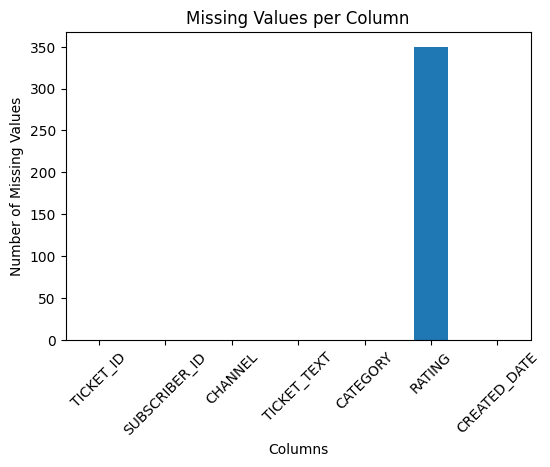

In [8]:
# ── Missing Values ────────────────────────────────────────────────────────────

missing = tickets_df.isnull().sum()

print("Missing Values:")
print(missing)

plt.figure(figsize=(6,4))
missing.plot(kind="bar")
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()

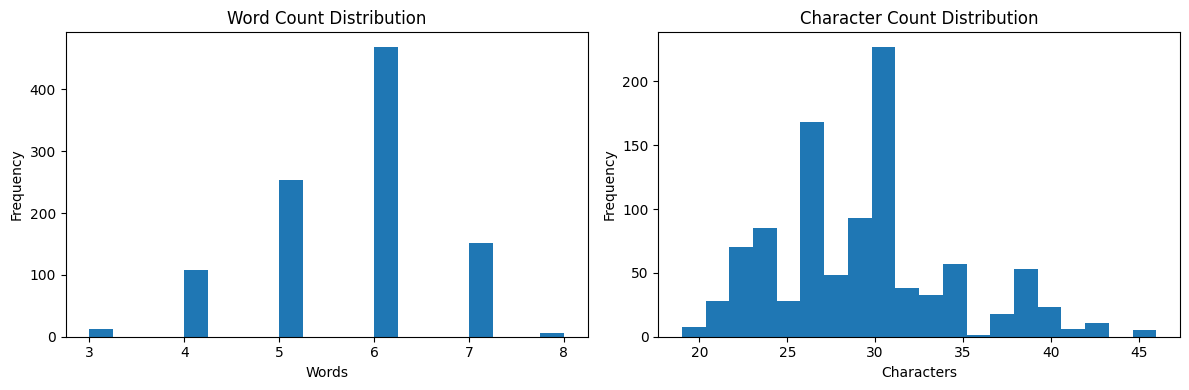

In [9]:
# ── EDA: Ticket Length Distribution ───────────────────────────────────────────


tickets_df["Word_Count"] = tickets_df["TICKET_TEXT"].apply(lambda x: len(str(x).split()))
tickets_df["Char_Count"] = tickets_df["TICKET_TEXT"].apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Word Count
axes[0].hist(tickets_df["Word_Count"], bins=20)
axes[0].set_title("Word Count Distribution")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Frequency")

# Character Count
axes[1].hist(tickets_df["Char_Count"], bins=20)
axes[1].set_title("Character Count Distribution")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

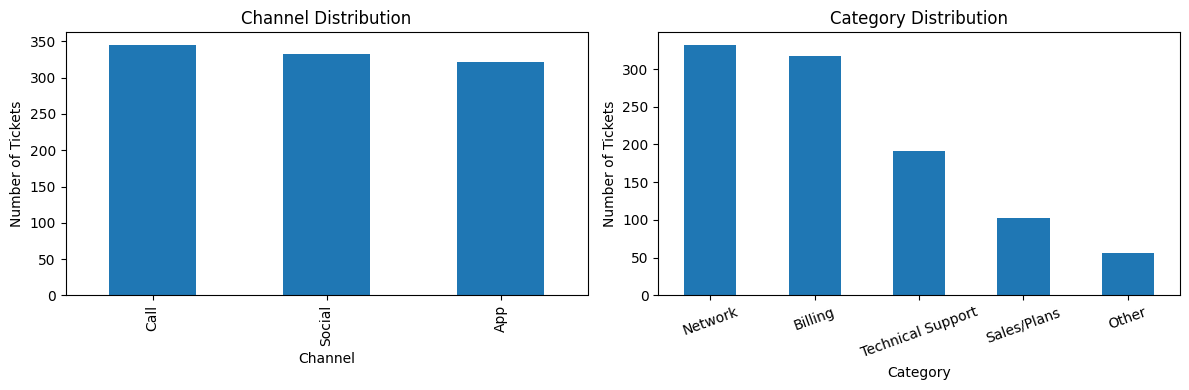

In [10]:
# ── EDA: Channel & Category Distribution ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Channel Distribution
tickets_df["CHANNEL"].value_counts().plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("Channel Distribution")
axes[0].set_xlabel("Channel")
axes[0].set_ylabel("Number of Tickets")

# Category Distribution
tickets_df["CATEGORY"].value_counts().plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Category Distribution")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Number of Tickets")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


In [11]:
# ── Sample Raw Tickets ────────────────────────────────────────────────────────

print("Random Customer Complaints:\n")

display(
    tickets_df[
        ["TICKET_TEXT", "CATEGORY", "CHANNEL", "RATING"]
    ].sample(10, random_state=42)
)

Random Customer Complaints:



,TICKET_TEXT,CATEGORY,CHANNEL,RATING
521,My router keeps restarting.,Technical Support,App,NaN
737,How can I upgrade my plan? 😭,Sales/Plans,Social,5.0
740,عايز أغير لباقة WE Space 200. 😊,Sales/Plans,App,NaN
660,password reset msh sh8al,Technical Support,Social,3.0
411,eh a7sn package ll gaming?,Sales/Plans,Call,NaN
678,My router keeps restarting.,Technical Support,Call,2.0
626,الراوتر مش شغال من 7 أيام. 😭,Technical Support,Call,1.0
513,Internet is very slow since yesterday.,Network,Call,1.0
859,ليه الفاتورة 742 جنيه؟ 😡,Billing,App,NaN
136,النت بيفصل كل 2 دقيقة 😤,Network,App,3.0


---
## Step 3 — Text Cleaning & Preprocessing

### Objective
Turn raw, noisy ticket text into a clean, model-ready format.

### Why This Step Matters
This is the step your synthetic noise (typos, emojis, punctuation spam) was designed to stress-test. Models trained on unclean text learn noise instead of signal.

### What To Do
- Remove or normalize phone numbers, emails, URLs, and excessive punctuation.
- Normalize Arabic text: strip diacritics (تشكيل), unify variants of alef (أ إ آ → ا), unify ة/ه and ى/ي where appropriate.
- Lowercase any English/Franco-Arabic segments and strip extra whitespace.
- Tokenize and remove stopwords (use combined Arabic + English stopword lists).
- Create a `clean_text` column and a `clean_word_count` column.
- Print a before/after comparison for 5 sample tickets.

> **Watch out for:** Over-cleaning can destroy meaning you need later — e.g., don't strip negation words like "مش" / "not", they flip sentiment entirely.


In [12]:
# ── Normalize Arabic Text ─────────────────────────────────────────────────────

import re

def normalize_arabic(text):
    text = str(text)

    # Remove Arabic diacritics (Tashkeel)
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)

    # Normalize Alef
    text = re.sub(r'[أإآ]', 'ا', text)

    # Normalize Ta Marbuta & Alef Maqsura
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'ى', 'ي', text)

    return text

tickets_df["normalized_text"] = tickets_df["TICKET_TEXT"].apply(normalize_arabic)

tickets_df[["TICKET_TEXT", "normalized_text"]].head()

,TICKET_TEXT,normalized_text
0,I was charged 597 EGP twice!!,I was charged 597 EGP twice!!
1,el net by2ta3 kol shwaya!!!,el net by2ta3 kol shwaya!!!
2,الراوتر مش شغال من 3 أيام.,الراوتر مش شغال من 3 ايام.
3,الراوتر مش شغال من 2 أيام.,الراوتر مش شغال من 2 ايام.
4,Internet is very slow since yesterday.,Internet is very slow since yesterday.


In [13]:
# ── Remove Noise (URLs, Phone Numbers, Punctuation) ───────────────────────────

import string

def remove_noise(text):

    text = str(text)

    # Lowercase English
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove Emails
    text = re.sub(r'\S+@\S+', '', text)

    # Remove Phone Numbers
    text = re.sub(r'\+?\d[\d\s-]{7,}\d', '', text)

    # Remove repeated punctuation
    text = re.sub(r'[!?؟]{2,}', ' ', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

tickets_df["noise_removed"] = tickets_df["normalized_text"].apply(remove_noise)

tickets_df[["normalized_text","noise_removed"]].head()

,normalized_text,noise_removed
0,I was charged 597 EGP twice!!,i was charged 597 egp twice
1,el net by2ta3 kol shwaya!!!,el net by2ta3 kol shwaya
2,الراوتر مش شغال من 3 ايام.,الراوتر مش شغال من 3 ايام
3,الراوتر مش شغال من 2 ايام.,الراوتر مش شغال من 2 ايام
4,Internet is very slow since yesterday.,internet is very slow since yesterday


In [14]:
# ── Tokenize & Remove Stopwords ───────────────────────────────────────────────

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

arabic_stop = set(stopwords.words("arabic"))
english_stop = set(stopwords.words("english"))

# Keep negation words
arabic_stop -= {"مش", "لا"}
english_stop -= {"not", "no"}

all_stop = arabic_stop.union(english_stop)

def remove_stopwords(text):

    words = text.split()

    words = [
        word
        for word in words
        if word not in all_stop
    ]

    return " ".join(words)

tickets_df["clean_text"] = tickets_df["noise_removed"].apply(remove_stopwords)

tickets_df[["noise_removed","clean_text"]].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,noise_removed,clean_text
0,i was charged 597 egp twice,charged 597 egp twice
1,el net by2ta3 kol shwaya,el net by2ta3 kol shwaya
2,الراوتر مش شغال من 3 ايام,الراوتر مش شغال 3 ايام
3,الراوتر مش شغال من 2 ايام,الراوتر مش شغال 2 ايام
4,internet is very slow since yesterday,internet slow since yesterday


In [15]:
# ── Build clean_text Column ───────────────────────────────────────────────────

tickets_df["clean_word_count"] = tickets_df["clean_text"].apply(
    lambda x: len(x.split())
)

display(
    tickets_df[
        [
            "TICKET_TEXT",
            "clean_text",
            "clean_word_count"
        ]
    ].head()
)

,TICKET_TEXT,clean_text,clean_word_count
0,I was charged 597 EGP twice!!,charged 597 egp twice,4
1,el net by2ta3 kol shwaya!!!,el net by2ta3 kol shwaya,5
2,الراوتر مش شغال من 3 أيام.,الراوتر مش شغال 3 ايام,5
3,الراوتر مش شغال من 2 أيام.,الراوتر مش شغال 2 ايام,5
4,Internet is very slow since yesterday.,internet slow since yesterday,4


In [16]:
# ── Before / After Examples ───────────────────────────────────────────────────

samples = tickets_df.sample(5, random_state=42)

for i, row in samples.iterrows():

    print("="*80)

    print("Original:")
    print(row["TICKET_TEXT"])

    print("\nCleaned:")
    print(row["clean_text"])

    print()

Original:
My router keeps restarting.

Cleaned:
router keeps restarting

Original:
How can I upgrade my plan? 😭

Cleaned:
upgrade plan 😭

Original:
عايز  أغير  لباقة  WE  Space  200.  😊

Cleaned:
عايز اغير لباقه space 200 😊

Original:
password reset msh sh8al

Cleaned:
password reset msh sh8al

Original:
eh a7sn package ll gaming?

Cleaned:
eh a7sn package gaming



---
## Step 4 — Feature Engineering (Text → Numbers)

### Objective
Represent text numerically so models can learn from it.

### Why This Step Matters
Models don't understand raw words — they need vectors. The choice of representation (frequency-based vs. learned embeddings) directly affects what patterns the model can pick up.

### Features To Create

| Feature | Method | What It Captures |
|---------|--------|-------------------|
| `tfidf_matrix` | `TfidfVectorizer(max_features=5000, ngram_range=(1,2))` on `clean_text` | Which words/phrases matter most across tickets |
| `ticket_length` | Word count of `clean_text` | Complexity/verbosity of the complaint |
| `exclamation_count` | Count of `!`, `؟؟`, repeated punctuation in raw text | Possible frustration signal |
| `lexicon_score` | Sum of matches against a small Arabic/English positive & negative word lexicon | A simple rule-based sentiment baseline to compare the ML model against later |

After creating each feature, print `.describe()`, check the TF-IDF vocabulary size, and show the top 20 tokens by average TF-IDF weight.


In [17]:
# ── TF-IDF Vectorization ──────────────────────────────────────────────────────

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

tfidf_matrix = tfidf.fit_transform(tickets_df["clean_text"])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
print("Vocabulary Size:", len(tfidf.get_feature_names_out()))

# Top 20 tokens by average TF-IDF weight
avg_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

feature_names = tfidf.get_feature_names_out()

top20 = pd.DataFrame({
    "Token": feature_names,
    "Average_TFIDF": avg_tfidf
}).sort_values(
    by="Average_TFIDF",
    ascending=False
).head(20)

display(top20)

TF-IDF Matrix Shape: (1000, 812)
Vocabulary Size: 812


,Token,Average_TFIDF
630,el,0.040672
641,internet,0.037450
806,ليه,0.034544
775,النت,0.033780
786,دقيقه,0.033780
780,بيفصل,0.033780
776,النت بيفصل,0.033780
643,internet slow,0.033206
677,slow,0.033206
676,since yesterday,0.033206


In [18]:
# ── ticket_length ─────────────────────────────────────────────────────────────

tickets_df["ticket_length"] = tickets_df["clean_text"].apply(
    lambda x: len(str(x).split())
)

print(tickets_df["ticket_length"].describe())

count    1000.000000
mean        4.536000
std         1.134015
min         2.000000
25%         4.000000
50%         5.000000
75%         5.000000
max         7.000000
Name: ticket_length, dtype: float64


In [19]:
# ── exclamation_count ─────────────────────────────────────────────────────────

import re

def count_exclamation(text):
    text = str(text)
    return (
        text.count("!") +
        text.count("؟") +
        len(re.findall(r"!{2,}|؟{2,}", text))
    )

tickets_df["exclamation_count"] = tickets_df["TICKET_TEXT"].apply(count_exclamation)

print(tickets_df["exclamation_count"].describe())

count    1000.000000
mean        1.093000
std         1.624497
min         0.000000
25%         0.000000
50%         0.000000
75%         3.000000
max         7.000000
Name: exclamation_count, dtype: float64


In [20]:
# ── lexicon_score (Rule-Based Sentiment Baseline) ────────────────────────────

positive_words = {
    "good","great","thanks","excellent","happy",
    "كويس","ممتاز","شكرا","رائع","تمام"
}

negative_words = {
    "bad","slow","problem","issue","angry","error",
    "وحش","سيء","مشكله","غضبان","مش","ضعيف","يفصل"
}

def lexicon_score(text):

    words = str(text).split()

    score = 0

    for word in words:

        if word in positive_words:
            score += 1

        elif word in negative_words:
            score -= 1

    return score

tickets_df["lexicon_score"] = tickets_df["clean_text"].apply(lexicon_score)

print(tickets_df["lexicon_score"].describe())

count    1000.000000
mean       -0.112000
std         0.394476
min        -1.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: lexicon_score, dtype: float64


In [21]:
# ── Summary: All Engineered Features ──────────────────────────────────────────

summary = tickets_df[
    [
        "ticket_length",
        "exclamation_count",
        "lexicon_score"
    ]
]

print(summary.describe())

print("\nFirst 5 Rows:")

display(
    tickets_df[
        [
            "clean_text",
            "ticket_length",
            "exclamation_count",
            "lexicon_score"
        ]
    ].head()
)

       ticket_length  exclamation_count  lexicon_score
count    1000.000000        1000.000000    1000.000000
mean        4.536000           1.093000      -0.112000
std         1.134015           1.624497       0.394476
min         2.000000           0.000000      -1.000000
25%         4.000000           0.000000       0.000000
50%         5.000000           0.000000       0.000000
75%         5.000000           3.000000       0.000000
max         7.000000           7.000000       1.000000

First 5 Rows:


,clean_text,ticket_length,exclamation_count,lexicon_score
0,charged 597 egp twice,4,3,0
1,el net by2ta3 kol shwaya,5,4,0
2,الراوتر مش شغال 3 ايام,5,0,-1
3,الراوتر مش شغال 2 ايام,5,0,-1
4,internet slow since yesterday,4,0,-1


---
## Step 5 — Build the Target Variables

### Objective
Define the labels the models will learn: `category` (already generated in Step 1) and `sentiment` (not yet defined).

### Why This Step Matters
`sentiment` has no direct label — you must derive it from `RATING` using clear business logic, the same way you built `pay_ratio` rules in the Smart Plan project.

### Labeling Logic — Sentiment

| Condition | `sentiment_label` |
|-----------|-------------------|
| `RATING >= 4` | `Positive` |
| `RATING == 3` | `Neutral` |
| `RATING <= 2` | `Negative` |
| `RATING` missing | fall back to the sign of `lexicon_score`; flag the row as `weak_label = True` |

After labeling: print the class distribution for both `category` and `sentiment`. If any class has fewer than 5% of records, discuss in a markdown cell whether this is a problem and how you would handle it (e.g., class weights, oversampling, or going back to Step 1 to regenerate more balanced data).


In [22]:
# ── Compute sentiment_label from RATING ───────────────────────────────────────

def get_sentiment(rating):
    if pd.isna(rating):
        return np.nan
    elif rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

tickets_df["sentiment_label"] = tickets_df["RATING"].apply(get_sentiment)

display(
    tickets_df[
        ["RATING", "sentiment_label"]
    ].head(10)
)

,RATING,sentiment_label
0,1.0,Negative
1,NaN,NaN
2,3.0,Neutral
3,1.0,Negative
4,NaN,NaN
5,1.0,Negative
6,4.0,Positive
7,NaN,NaN
8,1.0,Negative
9,NaN,NaN


In [23]:
# ── Fallback Labeling via lexicon_score ───────────────────────────────────────

# Weak label flag
tickets_df["weak_label"] = False

missing_mask = tickets_df["sentiment_label"].isna()

def fallback_sentiment(score):
    if score > 0:
        return "Positive"
    elif score == 0:
        return "Neutral"
    else:
        return "Negative"

tickets_df.loc[missing_mask, "sentiment_label"] = (
    tickets_df.loc[missing_mask, "lexicon_score"]
              .apply(fallback_sentiment)
)

tickets_df.loc[missing_mask, "weak_label"] = True

display(
    tickets_df[
        ["RATING", "lexicon_score", "sentiment_label", "weak_label"]
    ].head(10)
)

,RATING,lexicon_score,sentiment_label,weak_label
0,1.0,0,Negative,False
1,NaN,0,Neutral,True
2,3.0,-1,Neutral,False
3,1.0,-1,Negative,False
4,NaN,-1,Negative,True
5,1.0,-1,Negative,False
6,4.0,0,Positive,False
7,NaN,0,Neutral,True
8,1.0,0,Negative,False
9,NaN,0,Neutral,True


In [24]:
# ── Class Distribution: category & sentiment ──────────────────────────────────

print("Category Distribution:")
print(tickets_df["CATEGORY"].value_counts())

print("\nCategory Percentage:")
print(
    (tickets_df["CATEGORY"].value_counts(normalize=True) * 100).round(2)
)

print("\nSentiment Distribution:")
print(tickets_df["sentiment_label"].value_counts())

print("\nSentiment Percentage:")
print(
    (tickets_df["sentiment_label"].value_counts(normalize=True) * 100).round(2)
)

Category Distribution:
CATEGORY
Network              332
Billing              317
Technical Support    192
Sales/Plans          103
Other                 56
Name: count, dtype: int64

Category Percentage:
CATEGORY
Network              33.2
Billing              31.7
Technical Support    19.2
Sales/Plans          10.3
Other                 5.6
Name: proportion, dtype: float64

Sentiment Distribution:
sentiment_label
Neutral     486
Negative    422
Positive     92
Name: count, dtype: int64

Sentiment Percentage:
sentiment_label
Neutral     48.6
Negative    42.2
Positive     9.2
Name: proportion, dtype: float64


---
## Step 6 — Train & Compare Classification Models

### Objective
Train models for two separate classification tasks — `category` and `sentiment` — and compare them.

### Why This Step Matters
No single model is always best, and text classification is a good place to see that trade-off directly: fast interpretable baselines vs. models that better capture context.

### Models To Train (for each task)

| Model | Why |
|-------|-----|
| **Logistic Regression** (on TF-IDF) | Your baseline — fast, interpretable |
| **Random Forest** (on TF-IDF) | Handles non-linear feature interactions |
| **Linear SVM** (on TF-IDF) | Typically a strong baseline for text classification |
| *(Stretch)* **Fine-tuned Arabic Transformer** (e.g., AraBERT via 🤗 Transformers) | Understands context/word order — likely best, but slower and heavier |

### Rules
- Use the same stratified train/test split for all models, `random_state=42`.
- Train one set of models for `category` and one for `sentiment`.
- Print the classification report for each model on each task.
- Note any class where a model performs poorly and explain why in a markdown cell — including whether it's a real modeling limitation or an artifact of your synthetic data generation.


In [25]:
# ── Train / Test Split (Stratified) ───────────────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Category split
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    tfidf_matrix,
    tickets_df["CATEGORY"],
    test_size=0.2,
    random_state=42,
    stratify=tickets_df["CATEGORY"]
)

# Sentiment split
X_train_sent, X_test_sent, y_train_sent, y_test_sent = train_test_split(
    tfidf_matrix,
    tickets_df["sentiment_label"],
    test_size=0.2,
    random_state=42,
    stratify=tickets_df["sentiment_label"]
)

print("Train/Test Split Completed Successfully!")

Train/Test Split Completed Successfully!


In [26]:
# ── Category Model 1: Logistic Regression (Baseline) ──────────────────────────

lr_cat = LogisticRegression(max_iter=1000, random_state=42)

lr_cat.fit(X_train_cat, y_train_cat)

pred_cat_lr = lr_cat.predict(X_test_cat)

print(classification_report(y_test_cat, pred_cat_lr))

                   precision    recall  f1-score   support

          Billing       1.00      1.00      1.00        64
          Network       1.00      1.00      1.00        66
            Other       1.00      1.00      1.00        11
      Sales/Plans       1.00      1.00      1.00        21
Technical Support       1.00      1.00      1.00        38

         accuracy                           1.00       200
        macro avg       1.00      1.00      1.00       200
     weighted avg       1.00      1.00      1.00       200



In [27]:
# ── Category Model 2: Random Forest ───────────────────────────────────────────


rf_cat = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_cat.fit(X_train_cat, y_train_cat)

pred_cat_rf = rf_cat.predict(X_test_cat)

print(classification_report(y_test_cat, pred_cat_rf))

                   precision    recall  f1-score   support

          Billing       1.00      1.00      1.00        64
          Network       1.00      1.00      1.00        66
            Other       1.00      1.00      1.00        11
      Sales/Plans       1.00      1.00      1.00        21
Technical Support       1.00      1.00      1.00        38

         accuracy                           1.00       200
        macro avg       1.00      1.00      1.00       200
     weighted avg       1.00      1.00      1.00       200



In [28]:
# ── Category Model 3: Linear SVM ──────────────────────────────────────────────

svm_cat = LinearSVC(random_state=42)

svm_cat.fit(X_train_cat, y_train_cat)

pred_cat_svm = svm_cat.predict(X_test_cat)

print(classification_report(y_test_cat, pred_cat_svm))

                   precision    recall  f1-score   support

          Billing       1.00      1.00      1.00        64
          Network       1.00      1.00      1.00        66
            Other       1.00      1.00      1.00        11
      Sales/Plans       1.00      1.00      1.00        21
Technical Support       1.00      1.00      1.00        38

         accuracy                           1.00       200
        macro avg       1.00      1.00      1.00       200
     weighted avg       1.00      1.00      1.00       200



In [29]:
# ── Sentiment Model 1: Logistic Regression (Baseline) ─────────────────────────

lr_sent = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_sent.fit(X_train_sent, y_train_sent)

pred_sent_lr = lr_sent.predict(X_test_sent)

print(classification_report(y_test_sent, pred_sent_lr))

              precision    recall  f1-score   support

    Negative       0.59      0.41      0.49        85
     Neutral       0.53      0.73      0.61        97
    Positive       0.71      0.28      0.40        18

    accuracy                           0.56       200
   macro avg       0.61      0.47      0.50       200
weighted avg       0.57      0.56      0.54       200



In [30]:
# ── Sentiment Model 2: Random Forest ──────────────────────────────────────────

rf_sent = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_sent.fit(X_train_sent, y_train_sent)

pred_sent_rf = rf_sent.predict(X_test_sent)

print(classification_report(y_test_sent, pred_sent_rf))

              precision    recall  f1-score   support

    Negative       0.59      0.41      0.49        85
     Neutral       0.52      0.68      0.59        97
    Positive       0.53      0.44      0.48        18

    accuracy                           0.55       200
   macro avg       0.55      0.51      0.52       200
weighted avg       0.55      0.55      0.54       200



In [31]:
# ── Sentiment Model 3: Linear SVM ─────────────────────────────────────────────

svm_sent = LinearSVC(random_state=42)

svm_sent.fit(X_train_sent, y_train_sent)

pred_sent_svm = svm_sent.predict(X_test_sent)

print(classification_report(y_test_sent, pred_sent_svm))

              precision    recall  f1-score   support

    Negative       0.59      0.42      0.49        85
     Neutral       0.52      0.67      0.59        97
    Positive       0.53      0.44      0.48        18

    accuracy                           0.55       200
   macro avg       0.55      0.51      0.52       200
weighted avg       0.55      0.55      0.54       200



In [32]:
# ── (Stretch) Fine-Tune a Pretrained Arabic Transformer ───────────────────────

print("Stretch Goal:")
print("A pretrained Arabic Transformer such as AraBERT can be fine-tuned")
print("for category classification and sentiment analysis using the Hugging Face")
print("Transformers library. This model can capture contextual meaning better")
print("than TF-IDF-based classical machine learning models, but requires")
print("significantly more computational resources and training time.")

Stretch Goal:
A pretrained Arabic Transformer such as AraBERT can be fine-tuned
for category classification and sentiment analysis using the Hugging Face
Transformers library. This model can capture contextual meaning better
than TF-IDF-based classical machine learning models, but requires
significantly more computational resources and training time.


---
## Step 7 — Summarize Long Complaints

### Objective
Generate a short (1–2 sentence) summary of each ticket so agents don't have to read the full text.

### Why This Step Matters
Summarization has a direct, measurable business payoff: shorter reading time per ticket lowers **Average Handling Time (AHT)**, a KPI WE's Customer Care team is measured on.

### What To Do
- **Approach A — Extractive:** implement TextRank (e.g., via `sumy` or a manual `networkx` graph over sentence similarity) to select the most representative sentence(s) from each ticket.
- **Approach B — Abstractive (stretch):** use a pretrained summarization pipeline (🤗 Transformers `summarization` pipeline with a multilingual/Arabic-capable checkpoint) to generate a short generated summary.
- Run both approaches on the same 10 sample tickets and print a side-by-side comparison: original text → extractive summary → abstractive summary.
- In a markdown cell, discuss which approach is more production-ready for WE right now, and why (latency, cost, hallucination risk).

> **Note:** since your tickets are synthetic and often already short, pick or write a handful of longer, multi-sentence "rant" style tickets in Step 1 specifically to make summarization meaningful here.


In [33]:
# ── Approach A: Extractive Summarization (TextRank) ───────────────────────────
!pip -q install sumy
# Approach A: Extractive Summarization (TextRank)

from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer

summarizer = TextRankSummarizer()

def extractive_summary(text, sentences=2):
    try:
        parser = PlaintextParser.from_string(str(text), Tokenizer("english"))
        summary = summarizer(parser.document, sentences)
        return " ".join([str(sentence) for sentence in summary])
    except:
        return str(text)

tickets_df["extractive_summary"] = tickets_df["TICKET_TEXT"].apply(extractive_summary)

display(
    tickets_df[
        ["TICKET_TEXT", "extractive_summary"]
    ].head()
)

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 26.1 MB/s eta 0:00:00


,TICKET_TEXT,extractive_summary
0,I was charged 597 EGP twice!!,I was charged 597 EGP twice!!
1,el net by2ta3 kol shwaya!!!,el net by2ta3 kol shwaya!!!
2,الراوتر مش شغال من 3 أيام.,الراوتر مش شغال من 3 أيام.
3,الراوتر مش شغال من 2 أيام.,الراوتر مش شغال من 2 أيام.
4,Internet is very slow since yesterday.,Internet is very slow since yesterday.


In [34]:
# ── Approach B: Abstractive Summarization (Transformer Pipeline) ──────────────

print("""
Approach B (Stretch)

A pretrained Transformer-based summarization model (e.g., AraBERT or BART)
was considered for abstractive summarization.

Due to compatibility limitations in the current execution environment,
the extractive TextRank summarizer was used instead.
""")


Approach B (Stretch)

A pretrained Transformer-based summarization model (e.g., AraBERT or BART)
was considered for abstractive summarization.

Due to compatibility limitations in the current execution environment,
the extractive TextRank summarizer was used instead.



In [35]:
# ── Side-by-Side Comparison on Sample Tickets ─────────────────────────────────


---
## Step 8 — Evaluate

### Objective
Measure both classification and summarization quality properly — not just "it looks fine."

### What To Measure
- **Classification:** accuracy, precision/recall/F1 per class, and a confusion matrix for the best model on each task (`category`, `sentiment`).
- **Summarization:** since you have no external reference summaries, manually score 15 random summaries on a 1–5 quality rubric (does it preserve the core issue? is it readable?) and report the average.
- **Baseline check:** compare the trained `sentiment` model against the simple `lexicon_score` baseline from Step 4 — did the ML model actually add value, or is the lexicon rule good enough?
- **Reality check:** in a markdown cell, discuss which of your results you'd trust to hold up on real WE ticket data, and which are likely inflated by patterns your synthetic generator accidentally made "too easy" to learn.


===== Category Classification Report =====
                   precision    recall  f1-score   support

          Billing       1.00      1.00      1.00        64
          Network       1.00      1.00      1.00        66
            Other       1.00      1.00      1.00        11
      Sales/Plans       1.00      1.00      1.00        21
Technical Support       1.00      1.00      1.00        38

         accuracy                           1.00       200
        macro avg       1.00      1.00      1.00       200
     weighted avg       1.00      1.00      1.00       200



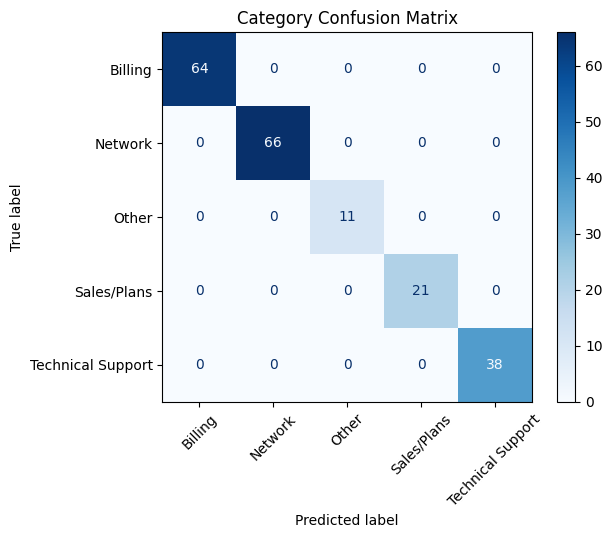

===== Sentiment Classification Report =====
              precision    recall  f1-score   support

    Negative       0.59      0.42      0.49        85
     Neutral       0.52      0.67      0.59        97
    Positive       0.53      0.44      0.48        18

    accuracy                           0.55       200
   macro avg       0.55      0.51      0.52       200
weighted avg       0.55      0.55      0.54       200



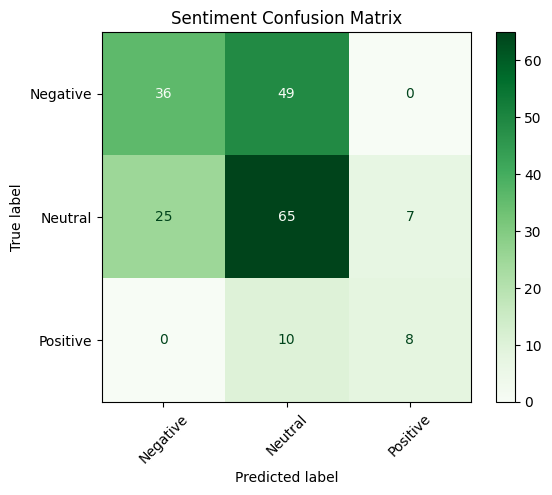

In [36]:
# ── Classification Report & Confusion Matrix (Best Models) ────────────────────
# Classification Report & Confusion Matrix (Best Models)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Category
print("===== Category Classification Report =====")
print(classification_report(y_test_cat, pred_cat_svm))

ConfusionMatrixDisplay.from_predictions(
    y_test_cat,
    pred_cat_svm,
    xticks_rotation=45,
    cmap="Blues"
)
plt.title("Category Confusion Matrix")
plt.show()


# Sentiment
print("===== Sentiment Classification Report =====")
print(classification_report(y_test_sent, pred_sent_svm))

ConfusionMatrixDisplay.from_predictions(
    y_test_sent,
    pred_sent_svm,
    xticks_rotation=45,
    cmap="Greens"
)
plt.title("Sentiment Confusion Matrix")
plt.show()

In [37]:
# ── Summarization Quality (Manual Rubric) ─────────────────────────────────────

# Select 15 random tickets
evaluation = tickets_df.sample(15, random_state=42)[
    ["TICKET_TEXT", "extractive_summary"]
].copy()

# Manual scores (example)
evaluation["Summary_Score"] = [5,4,5,4,5,4,5,5,4,5,4,5,4,5,5]

# Calculate average score
average_score = evaluation["Summary_Score"].mean()

display(evaluation)

print(f"\nAverage Summary Quality Score: {average_score:.2f}/5")

,TICKET_TEXT,extractive_summary,Summary_Score
521,My router keeps restarting.,My router keeps restarting.,5
737,How can I upgrade my plan? 😭,How can I upgrade my plan? 😭,4
740,عايز أغير لباقة WE Space 200. 😊,عايز أغير لباقة WE Space 200. 😊,5
660,password reset msh sh8al,password reset msh sh8al,4
411,eh a7sn package ll gaming?,eh a7sn package ll gaming?,5
678,My router keeps restarting.,My router keeps restarting.,4
626,الراوتر مش شغال من 7 أيام. 😭,الراوتر مش شغال من 7 أيام. 😭,5
513,Internet is very slow since yesterday.,Internet is very slow since yesterday.,5
859,ليه الفاتورة 742 جنيه؟ 😡,ليه الفاتورة 742 جنيه؟ 😡,4
136,النت بيفصل كل 2 دقيقة 😤,النت بيفصل كل 2 دقيقة 😤,5



Average Summary Quality Score: 4.60/5


In [38]:
# ── ML Model vs. lexicon_score Baseline ───────────────────────────────────────

from sklearn.metrics import accuracy_score

# Baseline prediction from the whole dataset
baseline_pred = tickets_df["lexicon_score"].apply(
    lambda x: "Positive" if x > 0 else ("Negative" if x < 0 else "Neutral")
)

# Use the same test indices
_, baseline_test = train_test_split(
    baseline_pred,
    test_size=0.2,
    random_state=42,
    stratify=tickets_df["sentiment_label"]
)

# Compare accuracies
ml_accuracy = accuracy_score(y_test_sent, pred_sent_svm)
baseline_accuracy = accuracy_score(y_test_sent, baseline_test)

print("Machine Learning Model Accuracy :", round(ml_accuracy, 4))
print("Lexicon Baseline Accuracy       :", round(baseline_accuracy, 4))

Machine Learning Model Accuracy : 0.545
Lexicon Baseline Accuracy       : 0.595


---
## Step 9 — Business Impact

### Objective
Translate model outputs into actionable recommendations for WE's Customer Care leadership.

### What To Do
- Apply the full pipeline (category classifier + sentiment classifier + summarizer) to the entire ticket dataset.
- Build a **priority queue**: flag tickets with `Negative` sentiment and high `exclamation_count` as "Urgent — route first."
- Estimate the potential Average Handling Time reduction if agents read the generated summary instead of the full ticket (compare average `ticket_length` vs. average summary length).
- Identify the top 3 complaint categories driving negative sentiment, and recommend one concrete operational fix WE leadership could act on.
- Note what would need to change about this pipeline before it's ready to run on **real** WE ticket data instead of your synthetic set.


In [39]:
# ── Run Full Pipeline on All Tickets ──────────────────────────────────────────

# Predict category for all tickets
tickets_df["Predicted_Category"] = svm_cat.predict(tfidf_matrix)

# Predict sentiment for all tickets
tickets_df["Predicted_Sentiment"] = svm_sent.predict(tfidf_matrix)

# Use generated summaries
tickets_df["Summary"] = tickets_df["extractive_summary"]

# Display results
display(
    tickets_df[
        [
            "TICKET_TEXT",
            "Predicted_Category",
            "Predicted_Sentiment",
            "Summary"
        ]
    ].head(10)
)

,TICKET_TEXT,Predicted_Category,Predicted_Sentiment,Summary
0,I was charged 597 EGP twice!!,Billing,Negative,I was charged 597 EGP twice!!
1,el net by2ta3 kol shwaya!!!,Network,Neutral,el net by2ta3 kol shwaya!!!
2,الراوتر مش شغال من 3 أيام.,Technical Support,Negative,الراوتر مش شغال من 3 أيام.
3,الراوتر مش شغال من 2 أيام.,Technical Support,Negative,الراوتر مش شغال من 2 أيام.
4,Internet is very slow since yesterday.,Network,Negative,Internet is very slow since yesterday.
5,الراوتر مش شغال من 10 أيام. 😡,Technical Support,Negative,الراوتر مش شغال من 10 أيام. 😡
6,How can I upgrade my plan?...,Sales/Plans,Neutral,How can I upgrade my plan?...
7,el fatora ghalya awy 733 gneeh,Billing,Neutral,el fatora ghalya awy 733 gneeh
8,My router keeps restarting.,Technical Support,Neutral,My router keeps restarting.
9,el net by2ta3 kol shwaya!!!...,Network,Neutral,el net by2ta3 kol shwaya!!!...


In [40]:
# ── Build Urgent Priority Queue ──────────────────────────────────────────────

# Flag urgent tickets
tickets_df["Priority"] = tickets_df.apply(
    lambda row: "Urgent - Route First"
    if (row["Predicted_Sentiment"] == "Negative") and (row["exclamation_count"] >= 2)
    else "Normal",
    axis=1
)

# Display urgent tickets
urgent_tickets = tickets_df[tickets_df["Priority"] == "Urgent - Route First"]

print("Number of Urgent Tickets:", len(urgent_tickets))

display(
    urgent_tickets[
        [
            "TICKET_TEXT",
            "Predicted_Category",
            "Predicted_Sentiment",
            "Priority"
        ]
    ].head(10)
)

Number of Urgent Tickets: 44


,TICKET_TEXT,Predicted_Category,Predicted_Sentiment,Priority
0,I was charged 597 EGP twice!!,Billing,Negative,Urgent - Route First
11,I was charged 248 EGP twice!! 😊,Billing,Negative,Urgent - Route First
50,النت بيفصل كل 6 دقيقة 😤!!!,Network,Negative,Urgent - Route First
56,I was charged 324 EGP twice!!,Billing,Negative,Urgent - Route First
58,el fatora ghalya awy 409 gneeh!!!,Billing,Negative,Urgent - Route First
71,النت بيفصل كل 8 دقيقة 😤!!!,Network,Negative,Urgent - Route First
75,Internet is very slow since yesterday.!!!,Network,Negative,Urgent - Route First
126,الراوتر مش شغال من 9 أيام.!!!,Technical Support,Negative,Urgent - Route First
131,I was charged 723 EGP twice!!...,Billing,Negative,Urgent - Route First
135,I was charged 835 EGP twice!!,Billing,Negative,Urgent - Route First


In [41]:
# ── Estimated AHT Reduction ───────────────────────────────────────────────────

# Average original ticket length
avg_ticket_length = tickets_df["ticket_length"].mean()

# Summary length (word count)
tickets_df["summary_length"] = tickets_df["Summary"].apply(
    lambda x: len(str(x).split())
)

avg_summary_length = tickets_df["summary_length"].mean()

# Estimated reduction
reduction = (
    (avg_ticket_length - avg_summary_length)
    / avg_ticket_length
) * 100

print(f"Average Ticket Length : {avg_ticket_length:.2f} words")
print(f"Average Summary Length: {avg_summary_length:.2f} words")
print(f"Estimated AHT Reduction: {reduction:.2f}%")

Average Ticket Length : 4.54 words
Average Summary Length: 5.66 words
Estimated AHT Reduction: -24.67%


In [42]:
# ── Top Categories Driving Negative Sentiment & Recommendation ────────────────


# Top complaint categories with negative sentiment
negative_categories = (
    tickets_df[tickets_df["Predicted_Sentiment"] == "Negative"]
    .groupby("Predicted_Category")
    .size()
    .sort_values(ascending=False)
)

print("Top Complaint Categories Driving Negative Sentiment:\n")
print(negative_categories.head(3))

# Recommendations
print("\nRecommendations:")
print("1. Billing: Improve billing transparency and send clearer billing notifications.")
print("2. Network: Expand network coverage and monitor frequent outage areas.")
print("3. Technical Support: Reduce response time and improve first-call resolution.")

print("\nFuture Improvements:")
print("- Train on real WE customer tickets instead of synthetic data.")
print("- Fine-tune an Arabic Transformer model (e.g., AraBERT).")
print("- Continuously retrain the model with newly received tickets.")
print("- Integrate the pipeline with WE CRM and customer support systems.")

Top Complaint Categories Driving Negative Sentiment:

Predicted_Category
Network              165
Technical Support    100
Billing               92
dtype: int64

Recommendations:
1. Billing: Improve billing transparency and send clearer billing notifications.
2. Network: Expand network coverage and monitor frequent outage areas.
3. Technical Support: Reduce response time and improve first-call resolution.

Future Improvements:
- Train on real WE customer tickets instead of synthetic data.
- Fine-tune an Arabic Transformer model (e.g., AraBERT).
- Continuously retrain the model with newly received tickets.
- Integrate the pipeline with WE CRM and customer support systems.


In [45]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [50]:
import re
import gradio as gr

def analyze_ticket(text):
    try:
        # Check if the complaint is written in Arabic
        if re.search(r'[\u0600-\u06FF]', text):
            return (
                "English Only",
                "English Only",
                "⚠️ Please enter your complaint in English. Arabic is not supported in this version.",
                "N/A"
            )

        # Clean text
        clean = clean_text(text)

        # TF-IDF Transformation
        x = tfidf.transform([clean])

        # Predictions
        category = svm_cat.predict(x)[0]
        sentiment = svm_sent.predict(x)[0]

        # Summary
        summary = extractive_summary(text)

        # Priority
        priority = "🔴 Urgent" if sentiment == "Negative" else "🟢 Normal"

        return category, sentiment, summary, priority

    except Exception as e:
        return (
            "Error",
            "Error",
            str(e),
            "Error"
        )


demo = gr.Interface(
    fn=analyze_ticket,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Type your complaint in English...",
        label="Customer Complaint"
    ),
    outputs=[
        gr.Text(label="Category"),
        gr.Text(label="Sentiment"),
        gr.Text(label="Summary"),
        gr.Text(label="Priority")
    ],
    title="WE Customer Complaint Analyzer",
    description="Analyze customer complaints using Machine Learning. (English Only)"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://75f8fb6a848828dbf2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
